In [164]:
# %%writefile Ind_OBV_EX.py

import numpy as np
import pandas as pd

import QUANTAXIS as QA

import Ind_Model_Base

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import Analysis_Funs as af
import Sample_Tools as smpl
import Pretreat_Tools as pretreat


%load_ext autoreload
%autoreload 2
%aimport Analysis_Funs,Sample_Tools,Pretreat_Tools

class OBV(Ind_Model_Base.Ind_Model):
    '''能量潮指标改进版'''
    def __init__(self,data, frequence=QA.FREQUENCE.DAY):
        super().__init__(data, 'OBV_EX', frequence)
    
    def on_set_params_default(self):
        return {'SHORT':5, 'LONG':15}
        
    def on_indicator_structuring(self, data):
        return self.excute_for_multicode(data, self.kernel, **self.pramas)

    
    def on_desition_structuring(self, data, ind_data):
        """
        1.短期量价穿越长期,res为1，买入信号参考。
        2.相反则res为-1，卖出信号参考。
        """
        return pd.DataFrame({'res':ind_data['CROSS_JC'] + ind_data['CROSS_SC']*-1})
        
    def kernel(self,dataframe,SHORT=5,LONG=15):
        '''多空比率净额= [（收盘价－最低价）－（最高价-收盘价）] ÷（ 最高价－最低价）×V'''
        long_short_ratio=((dataframe.close - dataframe.low) - (dataframe.high - dataframe.close)) / (dataframe.high-dataframe.low) * dataframe.volume
        
        short =QA.EMA(long_short_ratio,SHORT)
        long = QA.EMA(long_short_ratio,LONG)
        

        CROSS_JC=QA.CROSS(short, long)
        CROSS_SC=QA.CROSS(long, short)

        return pd.DataFrame({'main':long_short_ratio,'CROSS_JC':CROSS_JC, 'CROSS_SC':CROSS_SC})
#         return pd.DataFrame({'main':long_short_ratio})
    
    
    def plot(self,figsize=(1120/72,420/72)) -> dict:
        fig = plt.figure(figsize=figsize)
        groups = self.ind_df.groupby(level=1)
        for idx,item in enumerate(groups):
            inds_ = item[1].reset_index('code',drop=True)
            ax = fig.add_subplot(len(groups),1,idx+1)
             
            inds_.plot(ax=ax,legend=True)
            ax.set_title(item[0],color='r', loc ='left', pad=-10)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
            plt.xticks(rotation = 0)
            
    
    def plot_mix(self,figsize=(1120/72,420/72)) -> dict:
        fig = plt.figure(figsize=figsize)
        groups = self.ind_df.groupby(level=1)
        def x1(item):
            inds_ = item.reset_index('code',drop=True)
            plt.plot(inds_['main'])
#             print(item.name)
        groups.apply(x1)
        plt.legend(groups.groups.keys())
        
    def self_test(self):
        data = get_sample_by_zs(name='上证50', end='2020-06-29', gap=250, only_main=True)
        df = resample_stockdata_low(data.data,freq="M")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


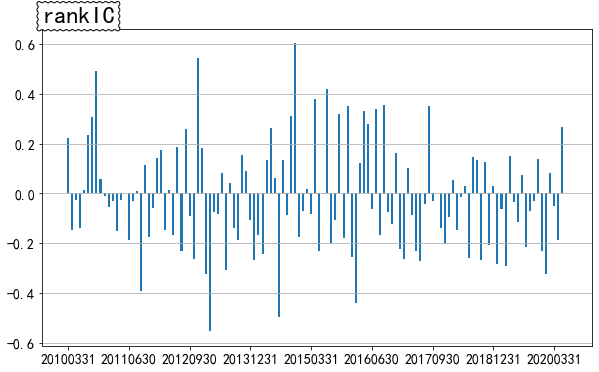

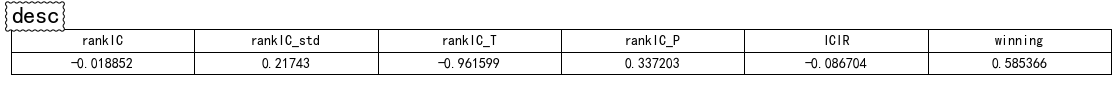

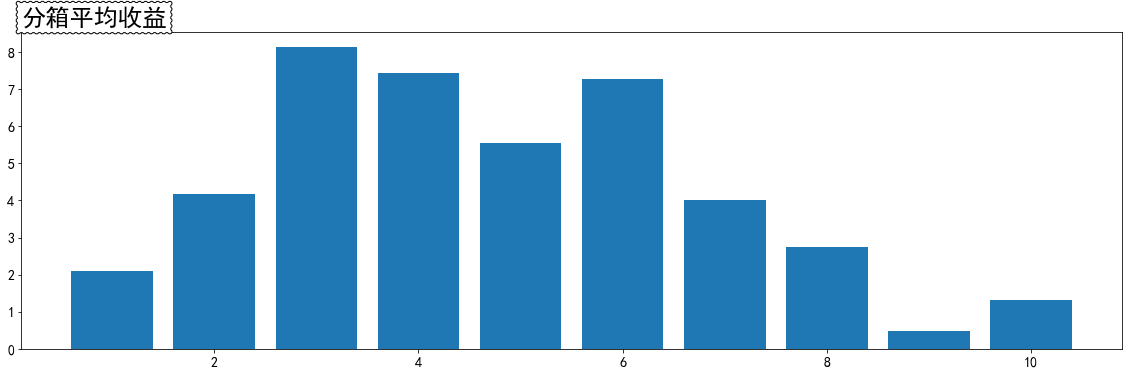

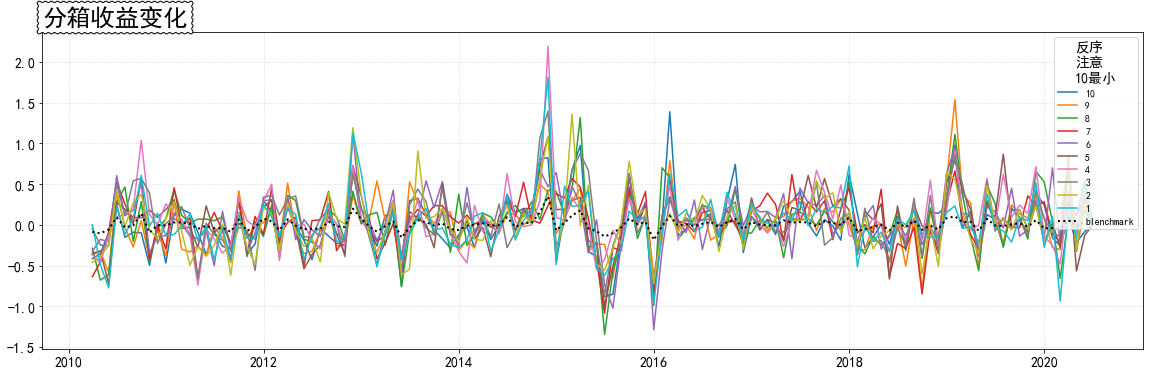

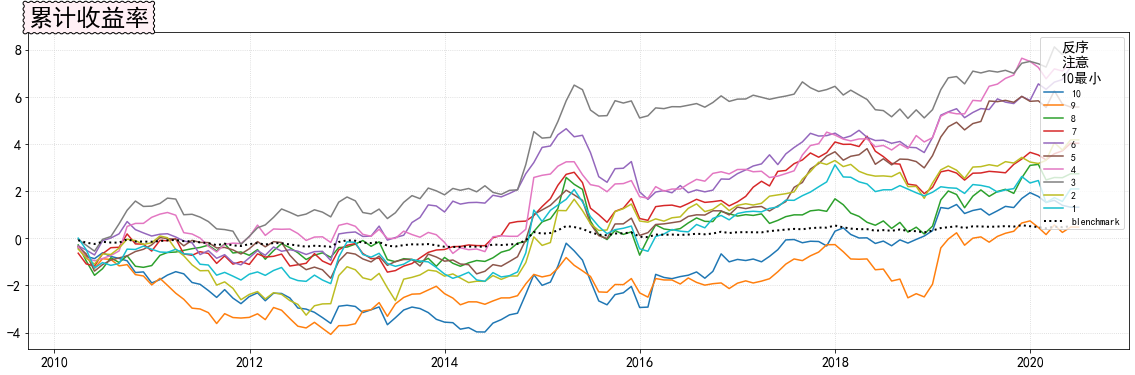

Wall time: 3.39 s


In [420]:
%%time
# data = smpl.get_sample_by_zs(name='上证50', end='2020-06-29', gap=2500, only_main=True)
# df = smpl.resample_stockdata_low(data.data,freq="m")
# ret_forward = smpl.get_forward_return(df,'close')


# obv = OBV(df)
# obv.fit()
# ind = obv.ind_df['main']
# factor_standardized = pretreat.standardize(ind, multi_code=True)
# rank_ic = af.get_rank_ic(factor_standardized, ret_forward)


fig = plt.figure(figsize=(1420/72/2,420/72))
ax = fig.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
ax.yaxis.grid()
plt.bar([pd.to_datetime(x).strftime('%Y%m%d') for x in rank_ic.index.values],rank_ic.fillna(0),width=0.5)
plt.title('rankIC',x=0, fontsize='xx-large',fontweight='black',horizontalalignment='left',bbox=dict(boxstyle='roundtooth',fc='lavenderblush', pad=0.25))
plt.show()


df_ = pd.DataFrame([af.get_ic_desc(rank_ic)], columns=['rankIC','rankIC_std','rankIC_T','rankIC_P'])
df_['ICIR']=round(af.get_ic_ir(rank_ic),6)
df_['winning']=round(af.get_winning_rate(rank_ic),6)

fig = plt.figure(figsize=(1420/72,420/72/7))
ax = fig.gca()
ax.xaxis.set_visible(False) 
ax.yaxis.set_visible(False)
ax.table(cellText=df_.values.round(6),colLabels=df_.columns,cellLoc='center', bbox = [0.0, 0.0, 1, 1],picker=True) 
plt.title('desc',x=0, fontsize='xx-large',fontweight='black',horizontalalignment='left',bbox=dict(boxstyle='roundtooth',fc='lavenderblush', pad=0.25))
plt.show()




ind_df = pd.concat([ind, ret_forward], axis=1)

blenchmark = smpl.get_benchmark(name='上证50', end='2020-06-29', gap=2500)
blenchmark_re = smpl.resample_stockdata_low(blenchmark.data,freq="m")
blenchmark_ret = smpl.get_forward_return(blenchmark_re,'close')
blenchmark_ret.reset_index('code',drop=True,inplace=True)
blenchmark_cum = blenchmark_ret.cumsum()
# 分箱
ind_binned = ind_df.groupby(level=0).apply(lambda x: pretreat.binning(x, deal_column='main',box_count=10, inplace=True))
# 去除绘图不需要的原始因子和code
ind_binned_noindex = ind_binned.reset_index().drop(['code', 'main'],axis=1)
# 按日期分组，组内再按分箱分组求总收益,结果会被倒序。
ind_binned_ret_date = ind_binned_noindex.set_index(['date', 'group_label']).groupby(level=0).apply(lambda x: x.groupby(level=1).apply(lambda y: y.sum()))

fig = plt.figure(figsize=(1420/72,420/72))
ind_binned_ret_all = ind_binned_noindex.drop(['date'],axis=1).set_index('group_label').groupby(level=0).apply(lambda x: x['ret_forward'].sum())
plt.bar(ind_binned_ret_all.index,ind_binned_ret_all)
plt.title('分箱平均收益',x=0, fontsize='xx-large',fontweight='black',horizontalalignment='left',bbox=dict(boxstyle='roundtooth',fc='white', pad=0.25))
plt.show()


fig = plt.figure(figsize=(1420/72,420/72))
ind_binned_ret_date.groupby(level=1).apply(lambda x: plt.plot(x.index.get_level_values(0).unique().tolist(),x.values.tolist(),label=x.index.get_level_values(1)[0]))
plt.plot(blenchmark_ret,linestyle=":", linewidth=2,color="black",label='blenchmark')
plt.legend(loc='upper right',fontsize='x-small',title='反序\n注意\n10最小')
plt.grid(linestyle="dotted",color="lightgray")
plt.title('分箱收益变化',x=0, fontsize='xx-large',fontweight='black',horizontalalignment='left',bbox=dict(boxstyle='roundtooth',fc='lavenderblush', pad=0.25))
plt.show()


ind_binned_ret_cum = ind_binned_ret_date.groupby(level=1).apply(lambda x: x.cumsum())
fig = plt.figure(figsize=(1420/72,420/72))
ind_binned_ret_cum.groupby(level=1).apply(lambda x: plt.plot(x.index.get_level_values(0).unique().tolist(),x.values.tolist(),label=x.index.get_level_values(1)[0]))
plt.plot(blenchmark_cum,linestyle=":", linewidth=2,color="black",label='blenchmark')
plt.legend(loc='upper right',fontsize='x-small',title='反序\n注意\n10最小')
plt.grid(linestyle="dotted",color="lightgray")
plt.title('累计收益率',x=0, fontsize='xx-large',fontweight='black',horizontalalignment='left',bbox=dict(boxstyle='roundtooth',fc='lavenderblush', pad=0.25))
plt.show()


# ind_binned_ret_date




In [224]:
ind_binned_ret_date.loc[('2020-02-29',1)].sum()

-0.9357372511672665

In [244]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(ind_binned_ret_date)
# 000016 上证50
# 000300 沪深300 
# def QA_fetch_index_day_adv(code,start,end=None)




# blenchmark = smpl.get_benchmark(name='上证50', end='2020-06-29', gap=250)
# blenchmark_re = smpl.resample_stockdata_low(blenchmark.data,freq="m")
# blenchmark_ret = smpl.get_forward_return(blenchmark_re,'close')
# blenchmark_ret.reset_index('code',drop=True,inplace=True)
# blenchmark_cum = blenchmark_ret.cumsum()

# print(blenchmark_re)
# print(blenchmark_ret)
# print(blenchmark_cum)
# fig = plt.figure(figsize=(1420/72,420/72))
# plt.plot(blenchmark_ret,color="red")
# plt.plot(blenchmark_cum,linestyle=":", linewidth=2,color="black")
# plt.show()


                        ret_forward
date       group_label             
2019-06-30 10              0.066104
           9               0.054612
           8               0.264497
           7               0.009982
           6               0.165129
           5               0.088575
           4              -0.025396
           3              -0.076733
           2               0.018145
           1              -0.035832
2019-07-31 10             -0.260058
           9              -0.224419
           8              -0.273448
           7               0.069335
           6              -0.039578
           5               0.868166
           4               0.622786
           3               0.090434
           2               0.081567
           1              -0.072790
2019-08-31 10              0.181021
           9               0.245163
           8               0.207628
           7              -0.027345
           6               0.450513
           5              -0

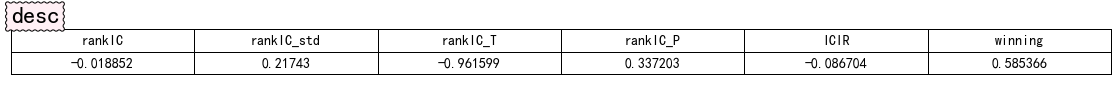

In [425]:
# blenchmark.close_pct_change?
# mean,std,t_static,p_value = af.get_ic_desc(rank_ic)

fig = plt.figure(figsize=(1420/72,420/72/7))
ax = fig.gca()
ax.xaxis.set_visible(False) 
ax.yaxis.set_visible(False)
ax.table(cellText=df_.values.round(6),colLabels=df_.columns,cellLoc='center', bbox = [0.0, 0.0, 1, 1]) 
d = dict(x=0, fontsize='xx-large',fontweight='black',horizontalalignment='left',bbox=dict(boxstyle='roundtooth',fc='lavenderblush', pad=0.25))
plt.title('desc',**d)
plt.show()